In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, 
                              roc_auc_score, 
                              confusion_matrix,
                              f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('C:\\Users\\hp\\predictive-maintenance-ml-datascience-project\\data\\ai4i2020.csv')
print(f"Shape : {df.shape}")
df.head()

Shape : (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
#
# Encoder la colonne Type (L/M/H)
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Renommer les colonnes pour éviter les caractères spéciaux (XGBoost n'accepte pas [, ], <)
df = df.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

# Sélection des features et target
features = [
    'Air_temperature_K',
    'Process_temperature_K',
    'Rotational_speed_rpm',
    'Torque_Nm',
    'Tool_wear_min',
    'Type_encoded'
]

X = df[features]
y = df['Machine failure']

print(f"Features : {features}")
print(f"Shape X  : {X.shape}")
print(f"Shape y  : {y.shape}")

Features : ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_encoded']
Shape X  : (10000, 6)
Shape y  : (10000,)


In [22]:
#Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"\nDistribution train :")
print(y_train.value_counts())
print(f"\nDistribution test :")
print(y_test.value_counts())

Train : (8000, 6)
Test  : (2000, 6)

Distribution train :
Machine failure
0    7729
1     271
Name: count, dtype: int64

Distribution test :
Machine failure
0    1932
1      68
Name: count, dtype: int64


## Modèle 1 : Logistic Regression

In [23]:
# Normalisation nécessaire pour la régression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC : {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.84      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.82      0.88      2000

ROC-AUC : 0.9062


## Modèle 2 : Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC : {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.56      0.68        68

    accuracy                           0.98      2000
   macro avg       0.93      0.78      0.84      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC : 0.9699


##  Modèle 3 : XGBoost

In [25]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale:.2f}")

xgb = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC : {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")

scale_pos_weight : 28.52



=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.79      0.73        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC : 0.9726


XGBoost est clairement le meilleur — F1 le plus élevé (0.73) ET le meilleur équilibre precision/recall sur les pannes. C'est lui qu'on garde.

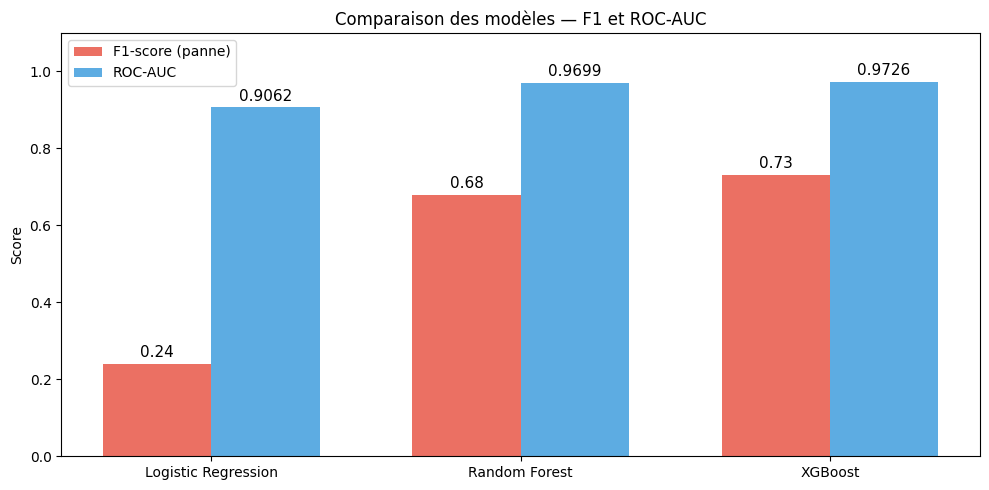

In [26]:
#Comparaison visuelle des modèles
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
f1_scores = [0.24, 0.68, 0.73]
roc_aucs = [0.9062, 0.9699, 0.9726]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, f1_scores, width, 
               label='F1-score (panne)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, roc_aucs, width, 
               label='ROC-AUC', color='#3498db', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — F1 et ROC-AUC')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

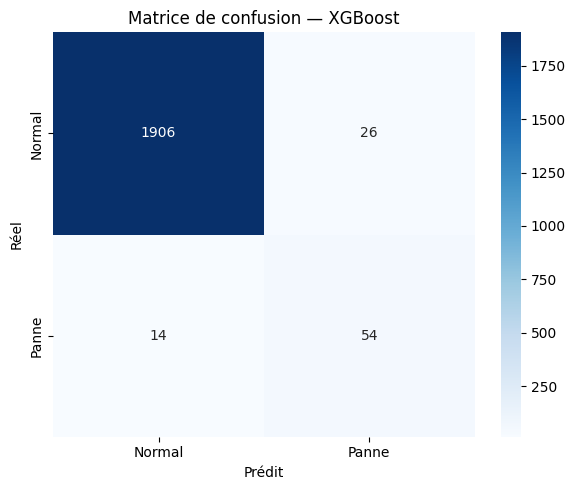

In [27]:
#Matrice de confusion XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Panne'],
            yticklabels=['Normal', 'Panne'])
plt.title('Matrice de confusion — XGBoost')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

In [28]:
#Sauvegarder le modèle
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(xgb, '../models/xgb_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

print("Modèles sauvegardés dans /models/")
print("  - xgb_model.pkl")
print("  - scaler.pkl")
print("  - label_encoder.pkl")

Modèles sauvegardés dans /models/
  - xgb_model.pkl
  - scaler.pkl
  - label_encoder.pkl
